<a href="https://colab.research.google.com/github/Love1117/Machine_learning-Projects/blob/main/Machine_Learning%20Project/03_Deep%20Learning%20Projects/Convolutional%20Neural%20Network%20(CNN)/Flower%20photos%20classification(5%20types)/flowe_dataset_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import matplotlib.pyplot as plt
import PIL
import os
import numpy as np
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

Mounted at /content/drive


In [3]:

dataset_dir = "/content/drive/My Drive/flower_dataset/flower_photos"

data_dir = pathlib.Path(dataset_dir)

print(data_dir)

/content/drive/My Drive/flower_dataset/flower_photos


In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))

print(image_count)

3670


In [5]:
flower_dict = {
    'daisy': 0,
    'dandelion': 1,
    'roses': 2,
    'sunflowers': 3,
    'tulips': 4
}

In [6]:
X = []
y = []

for flower_name in flower_dict:

    flower_folder = data_dir / flower_name

    for image_path in flower_folder.glob('*.jpg'):

        img = cv2.imread(str(image_path))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (180,180))

        X.append(img)

        y.append(flower_dict[flower_name])

In [7]:
X = np.array(X)
y = np.array(y)

X = X / 255.0

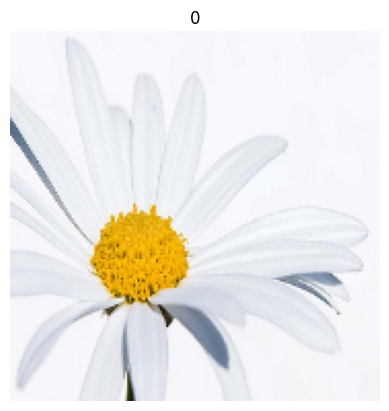

In [8]:
plt.imshow(X[0])
plt.title(y[0])
plt.axis("off")
plt.show()

In [9]:
print(X.shape)
print(y.shape)


(3670, 180, 180, 3)
(3670,)


#**Split Dataset**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#**Improved CNN Model With Data Augmentation**

In [12]:
data_augumentation = keras.Sequential([layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
                                       layers.RandomRotation(0.1),
                                       layers.RandomZoom(0.1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#**Build CNN Model**

In [15]:
model = Sequential([
        data_augumentation,

        layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(180,180,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.2),
    layers.Flatten(),


    layers.Dense(128, activation='relu'),

    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Compile Model**

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#**Training Model**

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_test, y_test))

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.4343 - loss: 1.2937 - val_accuracy: 0.5640 - val_loss: 1.1003
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.5950 - loss: 1.0084 - val_accuracy: 0.5872 - val_loss: 1.1021
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6540 - loss: 0.9046 - val_accuracy: 0.6499 - val_loss: 0.8958
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6778 - loss: 0.8379 - val_accuracy: 0.6485 - val_loss: 0.8903
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7020 - loss: 0.7810 - val_accuracy: 0.6390 - val_loss: 0.9437
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7061 - loss: 0.7590 - val_accuracy: 0.6458 - val_loss: 0.8635
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7115 - loss: 0.7252 - val_accuracy: 0.6703 - val_loss: 0.9256
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7388 - loss: 0.6919 - val_accuracy: 0.7112 - 

#**Evaluate Model**

In [18]:
model.evaluate(X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7548 - loss: 0.9133


[0.913317859172821, 0.7547683715820312]

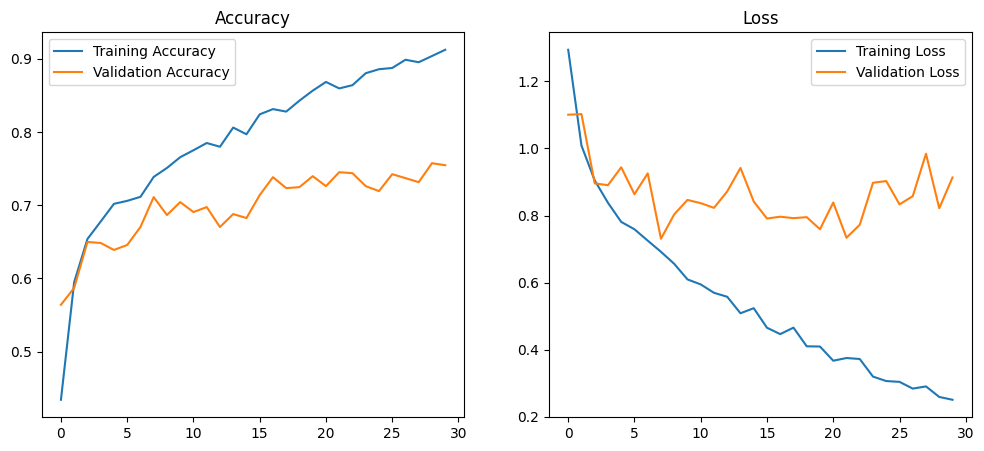

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(30)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [20]:
sample_image = X_test[0]

In [25]:
classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

#**Predict**

In [27]:
prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)

predicted_class = classes[np.argmax(prediction)]

print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
sunflowers


In [28]:
model.save("/content/drive/My Drive/flower_dataset/flower_classifier.keras")